# <font color="orange"> 10 — Coma y BAG </font>

Pipeline de análisis de dataset de ``Coma`` y comparación con data-iipsi (CN, AD, FTD). Mundo pequeño y criticalidad.

In [9]:
# === Configuración ===
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, "Thesis/Code")

from src.config import DEFAULT_PATHS, ExperimentConfig
from src.utils_seed import set_global_seed
from src.cohort import build_final_cohort_df
from src.splits import make_holdout_split
from src.data_io import load_fc_vectors_for_ids, vector_to_matrix
from src.vae_train import train_vae_final, load_vae_from_dir
from src.embeddings import encode_mu
from src.metrics import regression_metrics
from src.coma_data_io import (
    list_inflamacion_mats, load_fc_vectors_from_cohort,
    TOPO_COLUMNS, DEFAULT_GROUP_MAP,
)
from src.coma_graph import compute_topo_table, threshold_fixed, threshold_proportional
from src.utils_ids import normalize_record_id

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed

FC_ROOT = Path("/home/usuario/disco1/proyectos/2024-autoencoders/databases/fc/inflamacion")

OUT = Path("outputs/nb10_coma")
FIG = Path("figs")
VAE_DIR = OUT / "vae_redlat"
SW_OUT = OUT / "sw_metrics"
CRIT_OUT = OUT / "criticality"
THR_OUT = OUT / "threshold_sensitivity"
for p in [OUT, FIG, VAE_DIR, SW_OUT, CRIT_OUT, THR_OUT]:
    p.mkdir(parents=True, exist_ok=True)

paths = DEFAULT_PATHS
cfg = ExperimentConfig(seed=42, fisher_z=True, use_optuna=False)
set_global_seed(cfg.seed)
FISHER_Z = cfg.fisher_z

# Umbral TOPO: valor por defecto nb02; se revisa en §1b antes de calcular métricas
THRESHOLD_TOPO = 0.20
THR_FIXED_CANDIDATES = [0.10, 0.15, 0.20, 0.25, 0.30]
THR_PROP_REFERENCE = [0.05, 0.10, 0.15]  # comparación (criticalidad usa PROP=10%)
THR_NB02_REFERENCE = 0.20

VAE_NB08 = Path("outputs/nb08_thesis/vae_final")
REUSE_VAE = True
RETRAIN_IF_MISSING = True
RIDGE_ALPHA = 267.7

# --- Mundo pequeño (más robusto que nb08: 10/dx, N_NULL=20) ---
N_PER_DX = 50
N_NULL = 50
N_REWIRE = 10
N_JOBS = 8
QUICK_MODE = True   # False → todos los sujetos coma en SW

# --- Criticalidad (más robusto: 30/dx en nb08 → 50/dx aquí) ---
PROP_CRIT = 0.10
CRIT_N_PER_DX = 50
CRIT_N_JOBS = 2
N_AVALANCHAS = 50_000
N_BOOT_BRANCH = 1000
PROP_SENS = np.arange(0.02, 0.21, 0.02)  # 2%–20% sensibilidad λ₁

DIAG_COMA = ["CTRL", "ANOX", "TRAU"]
DIAG_REDLAT = ["CN", "AD", "FTD"]
PALETTE = {
    "CN": "#2166ac", "AD": "#d6604d", "FTD": "#4dac26",
    "CTRL": "#542788", "ANOX": "#807dba", "TRAU": "#9970ab",
    "coma":"lightblue", "redlat":"red"
}
COLORS_CRIT = {"CTRL": "#542788", "ANOX": "#807dba", "TRAU": "#9970ab"}

def build_z_topo(Z, topo):
    return np.hstack([np.asarray(Z, np.float32), np.asarray(topo, np.float32)])

def stratified_sample(df, n_per_dx, seed):
    parts = []
    for _, g in df.groupby("diagnosis"):
        n = min(n_per_dx, len(g))
        parts.append(g.sample(n=n, random_state=seed))
    return pd.concat(parts, ignore_index=True)

print("FC_ROOT:", FC_ROOT.exists())

FC_ROOT: True


## 1. Cohorte coma — inventario

Solo listamos sujetos; **TOPO se calcula después** de elegir umbral (§1b).

In [2]:
cohort_coma = list_inflamacion_mats(FC_ROOT, group_map=DEFAULT_GROUP_MAP)
cohort_coma.to_csv(OUT / "cohort_coma_index.csv", index=False)
print(cohort_coma.groupby("diagnosis").size())
print("Total:", len(cohort_coma))

diagnosis
ANOX     9
CTRL    19
TRAU    14
dtype: int64


## 1a. ANOX sintéticos (nb11)

Se agregan al inventario de coma si existe `outputs/nb11_anox_synth/`. `cohort_coma_meas` queda solo con medidos.

In [ ]:
ANOX_SYNTH_IDX = Path("outputs/nb11_anox_synth/anox_augmented_index.csv")
ANOX_SYNTH_MAT = Path("outputs/nb11_anox_synth/synthetic_mats")
USE_ANOX_SYNTH = True

cohort_coma_meas = cohort_coma.copy()
cohort_coma_meas["synthetic"] = False

if USE_ANOX_SYNTH and ANOX_SYNTH_IDX.exists():
    aug = pd.read_csv(ANOX_SYNTH_IDX)
    synth = aug.loc[aug["synthetic"] == True, ["record_id", "diagnosis"]].drop_duplicates("record_id")
    synth["mat_path"] = synth["record_id"].apply(
        lambda r: str((ANOX_SYNTH_MAT / f"{r}.mat").resolve())
    )
    missing = synth.loc[~synth["mat_path"].apply(lambda p: Path(p).exists()), "record_id"].tolist()
    if missing:
        raise FileNotFoundError(f"Faltan .mat sintéticos en {ANOX_SYNTH_MAT}: {missing[:3]}")
    synth["group_folder"] = "synthetic"
    synth["synthetic"] = True
    cohort_coma = pd.concat([cohort_coma_meas, synth], ignore_index=True)
    cohort_coma = cohort_coma.sort_values("record_id").reset_index(drop=True)
    cohort_coma.to_csv(OUT / "cohort_coma_augmented_index.csv", index=False)
    print("ANOX medidos:", int((cohort_coma_meas.diagnosis == "ANOX").sum()))
    print("ANOX synth:", len(synth))
    print(cohort_coma.groupby(["diagnosis", "synthetic"]).size())
    print("Total cohorte coma:", len(cohort_coma))
else:
    cohort_coma = cohort_coma_meas
    msg = "sin índice nb11" if USE_ANOX_SYNTH else "USE_ANOX_SYNTH=False"
    print(msg, "→ solo medidos")
    print(cohort_coma.groupby("diagnosis").size())

## 1b. Sensibilidad de umbral — ¿cuál usar?

**No hay un único umbral "óptimo"** sin definir el criterio. Cada elección implica un trade-off:

| Criterio | Qué mide | Preferís… |
|----------|----------|-----------|
| **A. Comparabilidad** | Mismo umbral que nb02 / ReDLaT (`graph_metrics_table.csv`) | Mantener **0.20** |
| **B. Conectividad** | % grafos conexos (mundo pequeño exige grafo conexo) | Umbral donde casi todos conecten |
| **C. Homogeneidad de densidad** | Densidad similar entre CTRL / ANOX / TRAU | Menor CV de densidad entre grupos |
| **D. Discriminación clínica** | Diferencias TOPO entre grupos (sin confundir con densidad) | Umbral proporcional o fijo + control de densidad |

**Umbral fijo** (Fisher-z ≥ T): simple y alineado con el pipeline previo, pero la **densidad varía** entre sujetos.

**Umbral proporcional** (top p% de aristas): **densidad fija** entre sujetos; mejor para comparar *forma* topológica (como en criticalidad). No es compatible directo con `outputs/graph_metrics_table.csv` (calculado a 0.20).

La celda siguiente explora candidatos y **recomienda** un umbral bajo criterios A+B; podés cambiar `THRESHOLD_TOPO` manualmente al final.

In [ ]:
import networkx as nx

N_ROI = 116
N_EDGES = N_ROI * (N_ROI - 1) / 2
ids_coma = cohort_coma["record_id"].tolist()
dx_map = cohort_coma.set_index("record_id")["diagnosis"]
fc_z_all = load_fc_vectors_from_cohort(cohort_coma, ids_coma, apply_fisher_z=FISHER_Z)
fc_mats = {rid: vector_to_matrix(v) for rid, v in zip(ids_coma, fc_z_all)}


def graph_props(fc_z, thr, kind="fixed"):
    B = threshold_fixed(fc_z, thr) if kind == "fixed" else threshold_proportional(fc_z, thr)
    density = float(B.sum() / 2 / N_EDGES)
    connected = nx.is_connected(nx.from_numpy_array(B))
    return density, connected


rows = []
for rid, fc in fc_mats.items():
    dx = dx_map[rid]
    for thr in THR_FIXED_CANDIDATES:
        d, conn = graph_props(fc, thr, "fixed")
        rows.append({"record_id": rid, "diagnosis": dx, "kind": "fixed", "param": thr,
                     "density": d, "connected": conn})
    for prop in THR_PROP_REFERENCE:
        d, conn = graph_props(fc, prop, "prop")
        rows.append({"record_id": rid, "diagnosis": dx, "kind": "prop", "param": prop,
                     "density": d, "connected": conn})

thr_df = pd.DataFrame(rows)
thr_df.to_csv(THR_OUT / "threshold_scan_per_subject.csv", index=False)


def summarize_thr(sub):
    by_dx = sub.groupby("diagnosis")["density"].mean()
    return pd.Series({
        "n": len(sub),
        "density_mean": sub["density"].mean(),
        "density_std": sub["density"].std(),
        "density_spread_dx": by_dx.std(),
        "pct_connected": 100 * sub["connected"].mean(),
    })

thr_summary = thr_df.groupby(["kind", "param"]).apply(summarize_thr).reset_index()
print("=== Resumen umbrales (cohorte coma) ===")
print(thr_summary.round(4).to_string(index=False))

# Kruskal global_efficiency por umbral fijo
for thr in THR_FIXED_CANDIDATES:
    tbl = compute_topo_table(cohort_coma, threshold=thr, apply_fisher_z=FISHER_Z)
    H, p = kruskal(*[tbl.loc[tbl.diagnosis == g, "global_efficiency"] for g in DIAG_COMA])
    print(f"  z={thr:.2f}  global_efficiency  Kruskal p={p:.4g}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sub_f = thr_df[thr_df.kind == "fixed"]
for dx in DIAG_COMA:
    g = sub_f[sub_f.diagnosis == dx].groupby("param")["density"].mean()
    axes[0].plot(g.index, g.values, "o-", label=dx)
axes[0].set_xlabel("Fisher-z fijo"); axes[0].set_ylabel("Densidad media")
axes[0].axvline(THR_NB02_REFERENCE, color="k", ls=":", label="nb02=0.20")
axes[0].legend(); axes[0].set_title("Densidad vs umbral fijo")

conn = sub_f.groupby("param")["connected"].mean() * 100
axes[1].bar([str(x) for x in conn.index], conn.values, color="steelblue")
axes[1].axhline(95, color="r", ls="--", label="95% conexos")
axes[1].set_xlabel("Fisher-z fijo"); axes[1].set_ylabel("% grafos conexos")
axes[1].legend(); axes[1].set_title("Conectividad vs umbral")
plt.tight_layout()
plt.savefig(FIG / "10_threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

# Selección: criterios A (nb02) + B (≥95% conexos)
candidates = thr_summary[thr_summary.kind == "fixed"].copy()
ok = candidates[candidates.pct_connected >= 95]
if ok.empty:
    ok = candidates.copy()
    print("⚠ Ningún umbral fijo deja ≥95% grafos conexos.")
ok = ok.assign(dist_nb02=(ok["param"] - THR_NB02_REFERENCE).abs())
ok = ok.sort_values(["pct_connected", "dist_nb02"], ascending=[False, True])
recommended = float(ok.iloc[0]["param"])

row_020 = candidates[candidates.param == THR_NB02_REFERENCE]
if not row_020.empty and row_020.iloc[0]["pct_connected"] >= 90:
    THRESHOLD_TOPO = THR_NB02_REFERENCE
    reason = f"0.20 → {row_020.iloc[0]['pct_connected']:.0f}% conexos; compatible nb02"
else:
    THRESHOLD_TOPO = recommended
    reason = f"0.20 insuficiente; auto → {recommended:.2f}"

print(f"\nRecomendación auto: {recommended:.2f}")
print(f"→ THRESHOLD_TOPO = {THRESHOLD_TOPO:.2f}  ({reason})")

topo_coma = compute_topo_table(cohort_coma, threshold=THRESHOLD_TOPO, apply_fisher_z=FISHER_Z)
topo_coma.to_csv(OUT / "graph_metrics_coma.csv", index=False)
with open(THR_OUT / "threshold_choice.json", "w") as f:
    json.dump({"THRESHOLD_TOPO": THRESHOLD_TOPO, "reason": reason,
               "recommended_auto": recommended}, f, indent=2)

## 2. data-iipsi — TOPO + VAE compartido

In [3]:
cohort_rl = build_final_cohort_df(
    paths.excel_path, paths.fc_folder, paths.t1w_csv_path,
    diagnoses_to_use=("CN", "AD", "FTD"),
)
graph_rl = pd.read_csv("outputs/graph_metrics_table.csv")
graph_rl["record_id"] = graph_rl["MRI_ID"].map(normalize_record_id)
graph_rl = graph_rl.drop_duplicates("record_id", keep="last")
topo_rl = graph_rl.set_index("record_id").loc[cohort_rl["record_id"], TOPO_COLUMNS].reset_index()
topo_rl["diagnosis"] = cohort_rl["diagnosis"].values
topo_rl["age"] = cohort_rl["age"].values

split = make_holdout_split(cohort_rl, seed=cfg.seed, test_size=cfg.test_size)
trainval_ids, test_ids = split["trainval_ids"], split["test_ids"]

X_tv = load_fc_vectors_for_ids(paths.fc_folder, trainval_ids, apply_fisher_z=FISHER_Z)
X_rl_all = load_fc_vectors_for_ids(
    paths.fc_folder, cohort_rl["record_id"].tolist(), apply_fisher_z=FISHER_Z,
)

if REUSE_VAE and (VAE_NB08 / "vae.weights.h5").exists():
    import shutil
    if not (VAE_DIR / "vae.weights.h5").exists():
        shutil.copytree(VAE_NB08, VAE_DIR, dirs_exist_ok=True)
    vae = load_vae_from_dir(VAE_DIR)
elif (VAE_DIR / "vae.weights.h5").exists():
    vae = load_vae_from_dir(VAE_DIR)
elif RETRAIN_IF_MISSING:
    VAE_HP = dict(
        hidden_dims=[512], latent_dim=64, beta_target=0.056663247229966504,
        warmup_ep=73, l2_reg=2.897389671945472e-07, lr=0.001892443497356961,
        recon_kind="mae", drop_rate=0.036861053246000725, activation="elu",
        norm_kind="layernorm", batch_size=64, clipnorm=1.0, epochs=96,
    )
    vae, _ = train_vae_final(X_tv, VAE_DIR, seed=cfg.seed, **VAE_HP)
else:
    raise FileNotFoundError("No hay VAE disponible")

rl_ids = cohort_rl["record_id"].tolist()
Z_rl = encode_mu(vae.encoder, X_rl_all)
ids_coma = cohort_coma["record_id"].tolist()
Z_coma = encode_mu(vae.encoder, load_fc_vectors_from_cohort(cohort_coma, ids_coma, apply_fisher_z=FISHER_Z))
topo_coma_mat = topo_coma.set_index("record_id").loc[ids_coma, TOPO_COLUMNS].to_numpy(np.float32)
topo_rl_mat = topo_rl.set_index("record_id").loc[rl_ids, TOPO_COLUMNS].to_numpy(np.float32)
print("Z RedLaT", Z_rl.shape, "| Z coma", Z_coma.shape)

E0000 00:00:1782778628.236433   84306 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782778628.236734   84398 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782778628.293339   84306 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Z RedLaT (1245, 64) | Z coma (42, 64)


## 3. Ridge(Z + TOPO → edad) — CN data-iipsi + predicción coma

In [4]:
cdf = cohort_rl.set_index("record_id")
z_map = dict(zip(rl_ids, Z_rl))
topo_map = dict(zip(rl_ids, topo_rl_mat))

def pack_rl(ids):
    Z = np.stack([z_map[i] for i in ids])
    T = np.stack([topo_map[i] for i in ids])
    y = cdf.loc[ids, "age"].to_numpy(float)
    dx = cdf.loc[ids, "diagnosis"].values
    return build_z_topo(Z, T), y, dx

X_tv, y_tv, dx_tv = pack_rl(trainval_ids)
X_te, y_te, dx_te = pack_rl(test_ids)
cn_mask = dx_tv == "CN"
sc = StandardScaler()
ridge = Ridge(alpha=RIDGE_ALPHA, random_state=cfg.seed)
ridge.fit(sc.fit_transform(X_tv[cn_mask]), y_tv[cn_mask])

mae_cn = mean_absolute_error(y_te[dx_te == "CN"], ridge.predict(sc.transform(X_te[dx_te == "CN"])))
print(f"MAE CN test (Z+TOPO): {mae_cn:.2f} años")

X_rl, y_rl, dx_rl = pack_rl(rl_ids)
pred_rl = ridge.predict(sc.transform(X_rl))
pred_df = pd.DataFrame({
    "record_id": rl_ids, "cohort": "redlat", "diagnosis": dx_rl,
    "age": y_rl, "predicted_age": pred_rl, "BAG_raw": pred_rl - y_rl,
})
pred_coma = ridge.predict(sc.transform(build_z_topo(Z_coma, topo_coma_mat)))
ref_cn_mean = pred_df.loc[pred_df.diagnosis == "CN", "predicted_age"].mean()
pred_coma_df = pd.DataFrame({
    "record_id": ids_coma, "cohort": "coma", "diagnosis": cohort_coma["diagnosis"].values,
    "age": np.nan, "predicted_age": pred_coma,
    "BAG_vs_CN_redlat": pred_coma - ref_cn_mean,
})
pred_all = pd.concat([pred_df, pred_coma_df], ignore_index=True)
pred_all.to_csv(OUT / "predicted_age_all_cohorts.csv", index=False)
print(pred_coma_df.groupby("diagnosis")["predicted_age"].mean().round(2))

MAE CN test (Z+TOPO): 6.72 años
diagnosis
ANOX    62.080002
CTRL    57.680000
TRAU    57.389999
Name: predicted_age, dtype: float32


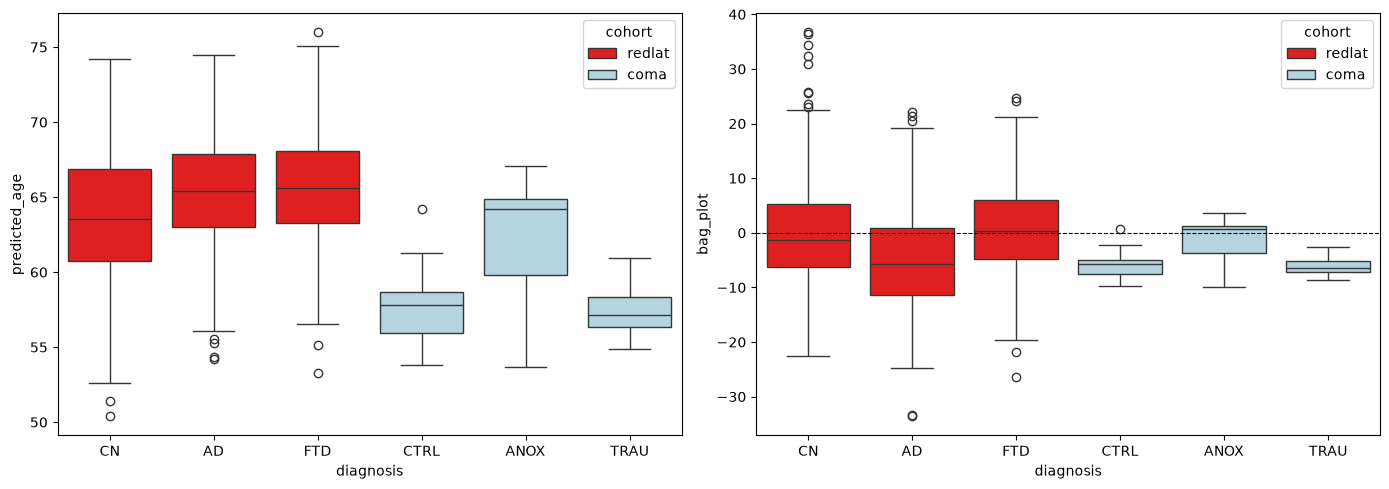

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ["CN", "AD", "FTD", "CTRL", "ANOX", "TRAU"]
sns.boxplot(data=pred_all, x="diagnosis", y="predicted_age", order=order,
            hue="cohort", dodge=False, ax=axes[0], palette=PALETTE)
sub_bag = pred_all.copy()
sub_bag["bag_plot"] = sub_bag["BAG_raw"]
sub_bag.loc[sub_bag.cohort == "coma", "bag_plot"] = sub_bag.loc[sub_bag.cohort == "coma", "BAG_vs_CN_redlat"]
sns.boxplot(data=sub_bag, x="diagnosis", y="bag_plot", order=order,
            hue="cohort", dodge=False, ax=axes[1], palette=PALETTE)
axes[1].axhline(0, color="k", ls="--", lw=0.8)
plt.tight_layout()
plt.savefig(FIG / "09_predicted_age_coma_vs_redlat.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Mundo pequeño (σ, ω) — N_PER_DX=50, N_NULL=50

In [10]:
import bct, networkx as nx

def graph_metrics_sw(B):
    C = float(np.mean(bct.clustering_coef_bu(B)))
    D = bct.distance_bin(B)
    L = float(bct.charpath(D, include_diagonal=False, include_infinite=False)[0])
    return C, L

def sw_one(row, fc_z, threshold, n_null, n_rewire, seed):
    B = threshold_fixed(fc_z, threshold)
    G = nx.from_numpy_array(B)
    p = float(B.sum()) / (B.shape[0] * (B.shape[0] - 1))
    if not nx.is_connected(G) or p == 0:
        return None
    C, L = graph_metrics_sw(B)
    n = B.shape[0]
    rng = np.random.default_rng(seed + hash(row["record_id"]) % 10000)
    Cs_er, Ls_er, C_ws, L_ws = [], [], [], []
    for _ in range(n_null):
        G_er = nx.erdos_renyi_graph(n, p, seed=int(rng.integers(1e6)))
        B_er = nx.to_numpy_array(G_er, dtype=float)
        np.fill_diagonal(B_er, 0)
        if nx.is_connected(G_er):
            c = float(np.mean(bct.clustering_coef_bu(B_er)))
            d = bct.distance_bin(B_er)
            l = float(bct.charpath(d, include_diagonal=False, include_infinite=False)[0])
            Cs_er.append(c); Ls_er.append(l)
        B_r = (bct.randmio_und(B, n_rewire)[0] > 0).astype(float)
        np.fill_diagonal(B_r, 0)
        if nx.is_connected(nx.from_numpy_array(B_r)):
            c, l = graph_metrics_sw(B_r)
            C_ws.append(c); L_ws.append(l)
    B_latt = (bct.latmio_und(B, n_rewire)[0] > 0).astype(float)
    np.fill_diagonal(B_latt, 0)
    C_latt = float(np.mean(bct.clustering_coef_bu(B_latt)))
    C_er, L_er = np.nanmean(Cs_er), np.nanmean(Ls_er)
    C_ws_m, L_ws_m = np.nanmean(C_ws), np.nanmean(L_ws)
    if not (C_ws_m and L and C_er and C_latt):
        return None
    return {
        "record_id": row["record_id"], "diagnosis": row["diagnosis"],
        "sigma_ws": (C / C_ws_m) / (L / L_ws_m),
        "sigma_er": (C / C_er) / (L / L_er),
        "omega_ws": (L_ws_m / L) - (C / C_latt),
        "C": C, "L": L,
    }

sw_sub = stratified_sample(cohort_coma[["record_id", "diagnosis"]], N_PER_DX, cfg.seed) if QUICK_MODE else cohort_coma
print(f"SW: n={len(sw_sub)} ({N_PER_DX}/dx, N_NULL={N_NULL})")
fc_z_map = {rid: vector_to_matrix(load_fc_vectors_from_cohort(cohort_coma, [rid], apply_fisher_z=FISHER_Z)[0])
            for rid in sw_sub["record_id"]}
rows_sw = Parallel(n_jobs=N_JOBS, verbose=1)(
    delayed(sw_one)(r.to_dict(), fc_z_map[r["record_id"]], THRESHOLD_TOPO, N_NULL, N_REWIRE, cfg.seed)
    for _, r in sw_sub.iterrows()
)
sw_df = pd.DataFrame([x for x in rows_sw if x])
sw_df.to_csv(SW_OUT / "sw_metrics.csv", index=False)
print(sw_df.groupby("diagnosis")[["sigma_ws", "sigma_er", "omega_ws"]].mean().round(3))

SW: n=42 (50/dx, N_NULL=50)


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


           sigma_ws  sigma_er  omega_ws
diagnosis                              
ANOX          1.381     1.812     0.074
CTRL          1.630     1.874     0.110
TRAU          1.584     2.044     0.140


[Parallel(n_jobs=8)]: Done  42 out of  42 | elapsed:  4.3min finished


sigma_ws: Kruskal-Wallis p=0.1258
sigma_er: Kruskal-Wallis p=0.2522
omega_ws: Kruskal-Wallis p=0.06551


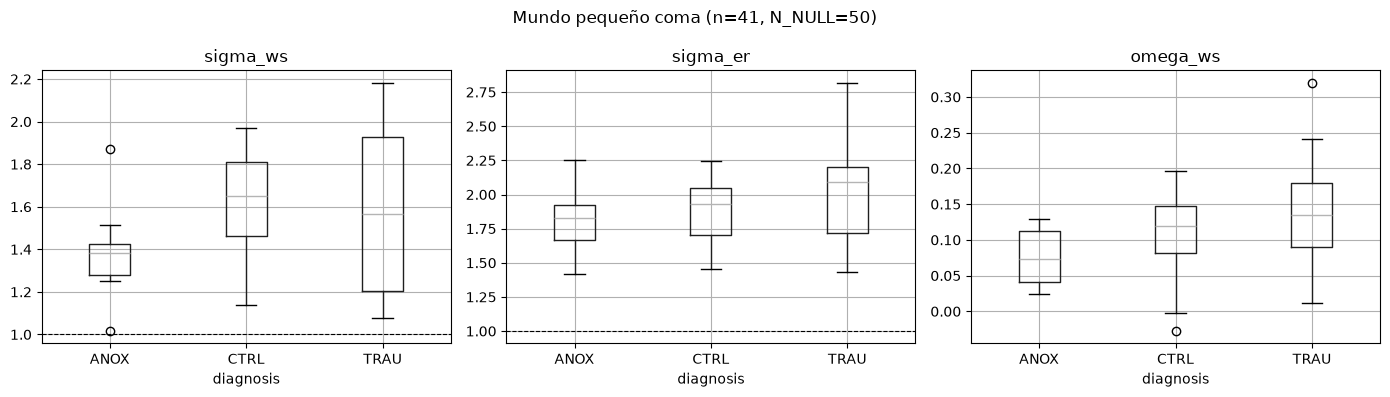

In [11]:
for col in ["sigma_ws", "sigma_er", "omega_ws"]:
    groups = [sw_df.loc[sw_df.diagnosis == g, col].dropna().values for g in DIAG_COMA]
    H, p = kruskal(*groups)
    print(f"{col}: Kruskal-Wallis p={p:.4g}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["sigma_ws", "sigma_er", "omega_ws"]):
    sw_df.boxplot(column=col, by="diagnosis", ax=ax)
    if "sigma" in col:
        ax.axhline(1.0, color="k", ls="--", lw=0.8)
    ax.set_title(col)
plt.suptitle(f"Mundo pequeño coma (n={len(sw_df)}, N_NULL={N_NULL})")
plt.tight_layout()
plt.savefig(FIG / "09_sw_by_diagnosis.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Criticalidad — λ₁, rango dinámico, referencia ER (cohorte completa coma)

In [12]:
import networkx as nx

N_ROI = 116
CRIT_SEED = cfg.seed
coma_idx = cohort_coma.set_index("record_id")

ids_c = cohort_coma["record_id"].tolist()
fc_z_crit = {rid: vector_to_matrix(v) for rid, v in zip(
    ids_c, load_fc_vectors_from_cohort(cohort_coma, ids_c, apply_fisher_z=FISHER_Z))}

# λ₁ individual (PROP=10%)
lambda1_records = []
for rid in ids_c:
    B = threshold_proportional(fc_z_crit[rid], PROP_CRIT)
    lambda1_records.append({
        "record_id": rid, "diagnosis": coma_idx.loc[rid, "diagnosis"],
        "lambda1": float(np.linalg.eigvalsh(B)[-1]),
    })
lambda1_df = pd.DataFrame(lambda1_records)
print(lambda1_df.groupby("diagnosis")["lambda1"].describe().round(2))

# matrices promedio grupales
fc_mean = {}
for g in DIAG_COMA:
    mats = [fc_z_crit[r] for r in ids_c if coma_idx.loc[r, "diagnosis"] == g]
    fc_mean[g] = np.mean(mats, axis=0)
adj_mean = {g: threshold_proportional(fc_mean[g], PROP_CRIT) for g in DIAG_COMA}
lambda1_mean = {g: float(np.linalg.eigvalsh(adj_mean[g])[-1]) for g in DIAG_COMA}

def er_lambda1_ref(density, n=N_ROI, n_ref=100, seed=42):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n_ref):
        G = nx.erdos_renyi_graph(n, density, seed=int(rng.integers(1e6)))
        A = nx.to_numpy_array(G, dtype=float)
        np.fill_diagonal(A, 0)
        out.append(np.linalg.eigvalsh(A)[-1])
    return float(np.mean(out))

er_ref = {}
for g in DIAG_COMA:
    dens = adj_mean[g].sum() / 2 / (N_ROI * (N_ROI - 1) / 2)
    mu_er = er_lambda1_ref(dens)
    er_ref[g] = mu_er
    print(f"{g}: λ₁={lambda1_mean[g]:.2f}  λ₁_ER={mu_er:.2f}  ratio={lambda1_mean[g]/mu_er:.2f}")

lambda1_df["lambda1_norm"] = lambda1_df.apply(
    lambda r: r["lambda1"] / er_ref[r["diagnosis"]], axis=1,
)

# rango dinámico Δ sobre matrices promedio
def simulate_response(A, h_vals, n_steps=500):
    n = A.shape[0]
    responses = np.zeros(len(h_vals))
    for i, h in enumerate(h_vals):
        F = np.zeros(n)
        for _ in range(n_steps):
            F_new = 1 - np.exp(-h - A @ F)
            if np.max(np.abs(F_new - F)) < 1e-9:
                break
            F = F_new
        responses[i] = F.mean()
    return responses

def dynamic_range(h_vals, F):
    F_norm = (F - F.min()) / (F.max() - F.min() + 1e-12)
    i01 = np.searchsorted(F_norm, 0.1)
    i09 = np.searchsorted(F_norm, 0.9)
    if i01 >= len(h_vals) or i09 >= len(h_vals) or h_vals[i01] <= 0:
        return np.nan
    return 10 * np.log10(h_vals[i09] / h_vals[i01])

h_vals = np.logspace(-5, 1, 300)
delta_vals = {g: dynamic_range(h_vals, simulate_response(adj_mean[g], h_vals)) for g in DIAG_COMA}
for g in DIAG_COMA:
    print(f"  {g}: Δ={delta_vals[g]:.2f} dB")

lambda1_df.to_csv(CRIT_OUT / "metricas_criticalidad.csv", index=False)

           count   mean   std    min    25%    50%    75%    max
diagnosis                                                       
ANOX         9.0  21.98  3.15  19.08  20.02  20.89  23.06  29.30
CTRL        19.0  17.37  1.93  14.68  15.81  17.16  18.51  22.40
TRAU        14.0  18.38  2.43  14.93  16.84  17.86  20.16  23.19
CTRL: λ₁=14.99  λ₁_ER=12.43  ratio=1.21
ANOX: λ₁=19.53  λ₁_ER=12.43  ratio=1.57
TRAU: λ₁=15.93  λ₁_ER=12.43  ratio=1.28
  CTRL: Δ=13.44 dB
  ANOX: Δ=18.66 dB
  TRAU: Δ=13.44 dB


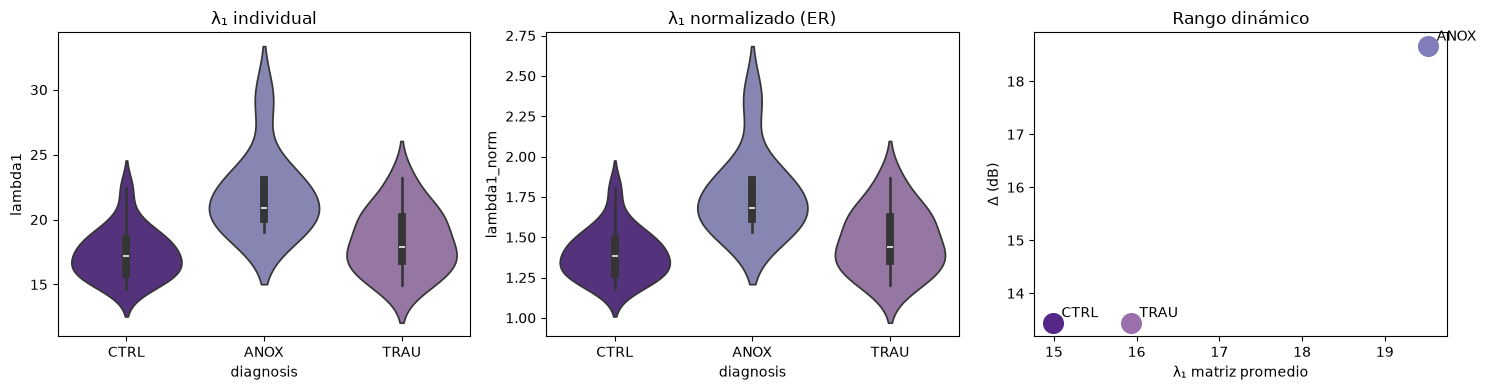

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.violinplot(data=lambda1_df, x="diagnosis", y="lambda1", order=DIAG_COMA,
               hue="diagnosis", palette=COLORS_CRIT, legend=False, ax=axes[0])
axes[0].set_title("λ₁ individual")
sns.violinplot(data=lambda1_df, x="diagnosis", y="lambda1_norm", order=DIAG_COMA,
               hue="diagnosis", palette=COLORS_CRIT, legend=False, ax=axes[1])
axes[1].set_title("λ₁ normalizado (ER)")
for g in DIAG_COMA:
    axes[2].scatter(lambda1_mean[g], delta_vals[g], s=200, color=COLORS_CRIT[g], label=g)
    axes[2].annotate(g, (lambda1_mean[g], delta_vals[g]), xytext=(6, 4), textcoords="offset points")
axes[2].set_xlabel("λ₁ matriz promedio"); axes[2].set_ylabel("Δ (dB)")
axes[2].set_title("Rango dinámico")
plt.tight_layout()
plt.savefig(FIG / "09_crit_lambda1.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Avalanchas (matrices promedio, N=50 000)

In [14]:
import powerlaw

np.random.seed(CRIT_SEED)
p_crit = 1.0 / lambda1_mean["CTRL"]
print(f"p = 1/λ₁_CTRL = {p_crit:.5f}")

def simulate_avalanches(A, p_activation, n_avalanchas):
    n = A.shape[0]
    nbrs = [np.where(A[i] > 0)[0] for i in range(n)]
    sizes, durations, generations = [], [], []
    for _ in range(n_avalanchas):
        active, visited = {np.random.randint(n)}, set()
        visited |= active
        gen_list = [1]
        while active:
            nxt = set()
            for node in active:
                for nb in nbrs[node]:
                    if nb not in visited and np.random.random() < p_activation:
                        nxt.add(nb); visited.add(nb)
            active = nxt
            if active:
                gen_list.append(len(active))
        sizes.append(len(visited))
        durations.append(len(gen_list))
        generations.append(gen_list)
    return np.array(sizes), np.array(durations), generations

avalanche_data, pl_results = {}, {}
for g in DIAG_COMA:
    print(f"Avalanchas {g}…")
    s, T, gens = simulate_avalanches(adj_mean[g], p_crit, N_AVALANCHAS)
    avalanche_data[g] = {"sizes": s, "durations": T, "generations": gens}
    fit_s = powerlaw.Fit(s[s > 1], discrete=True, verbose=False)
    fit_T = powerlaw.Fit(T[T > 1], discrete=True, verbose=False)
    pl_results[g] = {"alpha_s": fit_s.power_law.alpha, "alpha_T": fit_T.power_law.alpha}
    print(f"  ⟨s⟩={s.mean():.2f}  α(s)={pl_results[g]['alpha_s']:.3f}")

with open(CRIT_OUT / "avalanchas_pl.json", "w") as f:
    json.dump({g: {"mean_s": float(avalanche_data[g]["sizes"].mean()),
                   "alpha_s": float(pl_results[g]["alpha_s"]),
                   "alpha_T": float(pl_results[g]["alpha_T"])} for g in DIAG_COMA}, f, indent=2)

p = 1/λ₁_CTRL = 0.06671
Avalanchas CTRL…
  ⟨s⟩=3.70  α(s)=1.932
Avalanchas ANOX…
  ⟨s⟩=5.24  α(s)=1.762
Avalanchas TRAU…
  ⟨s⟩=4.35  α(s)=1.851


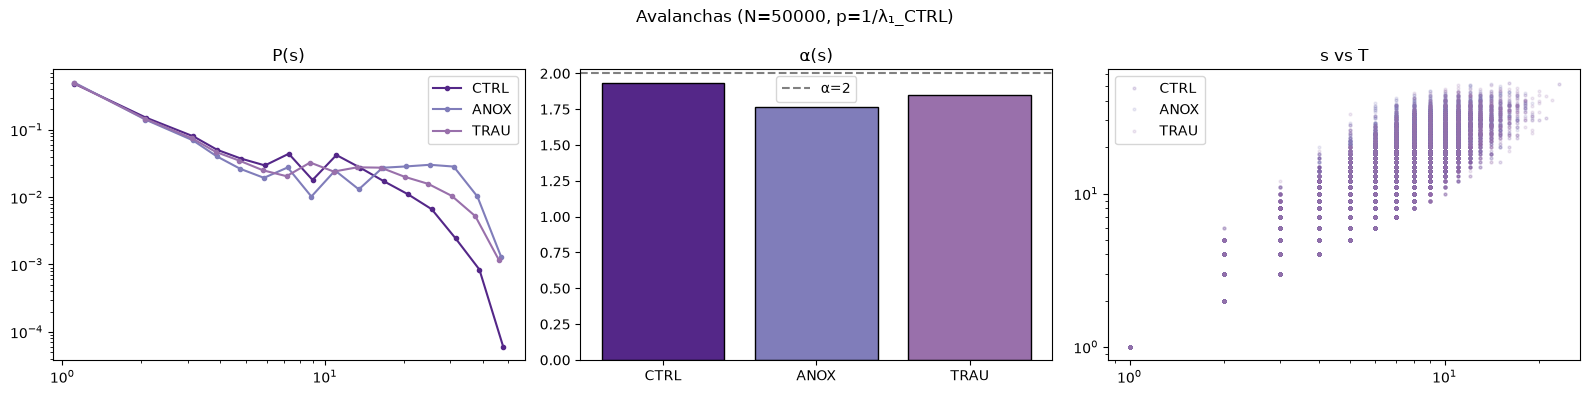

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for g in DIAG_COMA:
    s = avalanche_data[g]["sizes"]
    bins = np.logspace(0, np.log10(max(s)), 20)
    hist, edges = np.histogram(s, bins=bins)
    centers = np.sqrt(edges[:-1] * edges[1:])
    mask = hist > 0
    axes[0].loglog(centers[mask], hist[mask] / hist[mask].sum(), "o-", color=COLORS_CRIT[g], label=g, ms=3)
axes[0].set_title("P(s)"); axes[0].legend()
alpha_vals = [pl_results[g]["alpha_s"] for g in DIAG_COMA]
axes[1].bar(DIAG_COMA, alpha_vals, color=[COLORS_CRIT[g] for g in DIAG_COMA], edgecolor="k")
axes[1].axhline(2.0, color="gray", ls="--", label="α=2")
axes[1].set_title("α(s)"); axes[1].legend()
for g in DIAG_COMA:
    s, T = avalanche_data[g]["sizes"], avalanche_data[g]["durations"]
    axes[2].loglog(T, s, "o", color=COLORS_CRIT[g], alpha=0.15, ms=2, label=g)
axes[2].set_title("s vs T"); axes[2].legend()
plt.suptitle(f"Avalanchas (N={N_AVALANCHAS}, p=1/λ₁_CTRL)")
plt.tight_layout()
plt.savefig(FIG / "09_crit_avalanchas.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Percolación (CRIT_N_PER_DX=50)

In [16]:
PROPS_FINE = np.arange(0.002, 0.032, 0.002)
PROPS_COARSE = np.arange(0.040, 0.210, 0.010)
PROPS_PERC = np.round(np.concatenate([PROPS_FINE, PROPS_COARSE]), 3)

crit_sub = stratified_sample(cohort_coma[["record_id", "diagnosis"]], CRIT_N_PER_DX, CRIT_SEED)
print(f"Percolación: {len(crit_sub)} sujetos × {len(PROPS_PERC)} props")

def perc_one_subject(row, fc_z, props):
    rows = []
    for prop in props:
        B = threshold_proportional(fc_z, prop)
        comps = sorted(nx.connected_components(nx.from_numpy_array(B)), key=len, reverse=True)
        S1 = len(comps[0]) / N_ROI if comps else 0.0
        S2 = len(comps[1]) / N_ROI if len(comps) >= 2 else 0.0
        rows.append({"record_id": row["record_id"], "diagnosis": row["diagnosis"],
                     "prop": prop, "S1": S1, "S2": S2, "chi": S2**2 / N_ROI})
    return rows

perc_nested = Parallel(n_jobs=CRIT_N_JOBS, verbose=1)(
    delayed(perc_one_subject)(row.to_dict(), fc_z_crit[row["record_id"]], PROPS_PERC)
    for _, row in crit_sub.iterrows()
)
perc_df = pd.DataFrame([r for sub in perc_nested for r in sub])
perc_df.to_csv(CRIT_OUT / "percolacion.csv", index=False)

perc_agg = perc_df.groupby(["diagnosis", "prop"])[["S1", "S2", "chi"]].agg(["mean", "sem"]).reset_index()
perc_agg.columns = ["diagnosis", "prop", "S1_mean", "S1_sem", "S2_mean", "S2_sem", "chi_mean", "chi_sem"]
chi_peak = {}
for g in DIAG_COMA:
    sub = perc_agg[perc_agg.diagnosis == g]
    idx = sub["chi_mean"].idxmax()
    chi_peak[g] = float(sub.loc[idx, "prop"])
    print(f"  {g}: χ peak @ {chi_peak[g]*100:.1f}%")

Percolación: 42 sujetos × 32 props


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


  CTRL: χ peak @ 2.2%
  ANOX: χ peak @ 3.0%
  TRAU: χ peak @ 1.6%


[Parallel(n_jobs=2)]: Done  42 out of  42 | elapsed:    1.5s finished


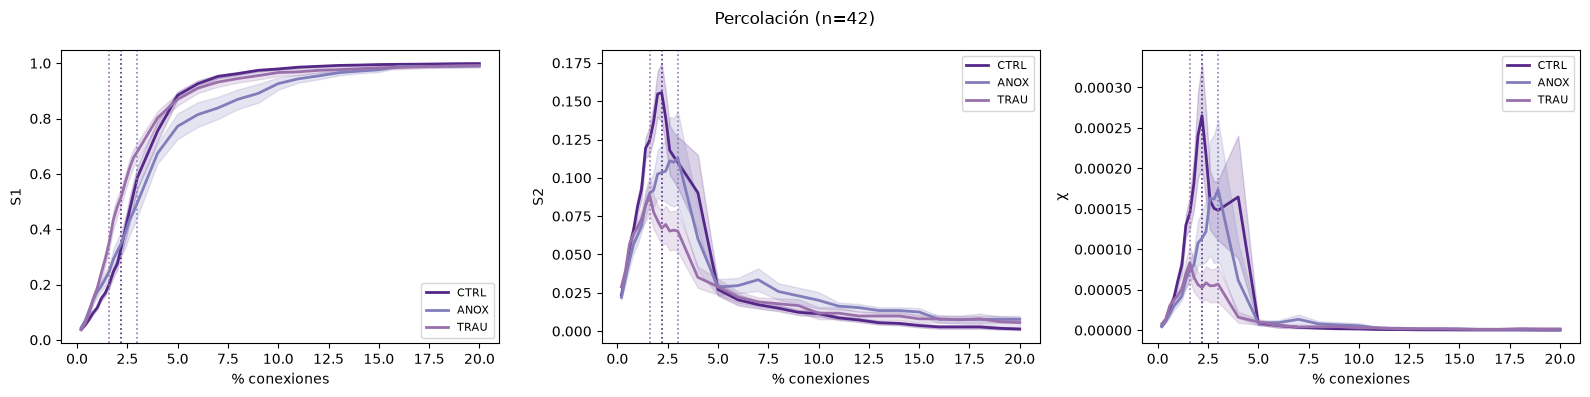

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for g in DIAG_COMA:
    sub = perc_agg[perc_agg.diagnosis == g]
    for ax, met in zip(axes, ["S1", "S2", "chi"]):
        ax.plot(sub["prop"] * 100, sub[f"{met}_mean"], color=COLORS_CRIT[g], lw=2, label=g)
        ax.fill_between(sub["prop"] * 100,
                        sub[f"{met}_mean"] - sub[f"{met}_sem"],
                        sub[f"{met}_mean"] + sub[f"{met}_sem"],
                        color=COLORS_CRIT[g], alpha=0.2)
        ax.axvline(chi_peak[g] * 100, color=COLORS_CRIT[g], ls=":", lw=1.2)
for ax, t in zip(axes, ["S1", "S2", "χ"]):
    ax.set_xlabel("% conexiones"); ax.set_ylabel(t); ax.legend(fontsize=8)
plt.suptitle(f"Percolación (n={len(crit_sub)})")
plt.tight_layout()
plt.savefig(FIG / "09_crit_percolacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Razón de ramificación σ_br

In [18]:
def compute_branching_ratio(generations):
    num, den = 0, 0
    for gen_list in generations:
        for t in range(len(gen_list) - 1):
            num += gen_list[t + 1]
            den += gen_list[t]
    return num / den if den > 0 else np.nan

branching_results = {}
for g in DIAG_COMA:
    gens = avalanche_data[g]["generations"]
    sigma_obs = compute_branching_ratio(gens)
    boot = []
    for _ in range(N_BOOT_BRANCH):
        idx = np.random.randint(0, len(gens), len(gens))
        boot.append(compute_branching_ratio([gens[i] for i in idx]))
    branching_results[g] = {
        "sigma": sigma_obs,
        "ci_low": float(np.percentile(boot, 2.5)),
        "ci_high": float(np.percentile(boot, 97.5)),
    }
    print(f"{g}: σ_br={sigma_obs:.4f}  IC95%[{branching_results[g]['ci_low']:.3f}, {branching_results[g]['ci_high']:.3f}]")

with open(CRIT_OUT / "branching_ratio.json", "w") as f:
    json.dump(branching_results, f, indent=2)

CTRL: σ_br=1.0681  IC95%[1.066, 1.070]
ANOX: σ_br=1.0450  IC95%[1.044, 1.046]
TRAU: σ_br=1.0541  IC95%[1.053, 1.055]


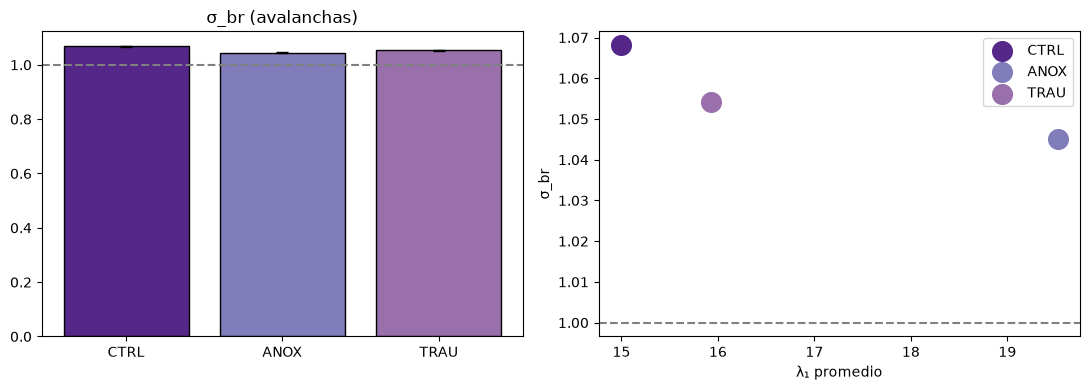

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sigmas = [branching_results[g]["sigma"] for g in DIAG_COMA]
yerr = [[s - branching_results[g]["ci_low"] for s, g in zip(sigmas, DIAG_COMA)],
        [branching_results[g]["ci_high"] - s for s, g in zip(sigmas, DIAG_COMA)]]
axes[0].bar(DIAG_COMA, sigmas, yerr=yerr, capsize=4,
            color=[COLORS_CRIT[g] for g in DIAG_COMA], edgecolor="k")
axes[0].axhline(1.0, color="gray", ls="--")
axes[0].set_title("σ_br (avalanchas)")
for g in DIAG_COMA:
    axes[1].scatter(lambda1_mean[g], branching_results[g]["sigma"],
                    color=COLORS_CRIT[g], s=200, label=g)
axes[1].axhline(1.0, color="gray", ls="--")
axes[1].set_xlabel("λ₁ promedio"); axes[1].set_ylabel("σ_br")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG / "09_crit_branching.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Sensibilidad de λ₁ (2%–20%, cohorte completa)

In [20]:
sens_rows = []
for prop in PROP_SENS:
    for rid in ids_c:
        B = threshold_proportional(fc_z_crit[rid], float(prop))
        sens_rows.append({
            "record_id": rid, "diagnosis": coma_idx.loc[rid, "diagnosis"],
            "prop": float(prop),
            "lambda1": float(np.linalg.eigvalsh(B)[-1]),
        })
sens_df = pd.DataFrame(sens_rows)
sens_agg = sens_df.groupby(["diagnosis", "prop"])["lambda1"].agg(["mean", "std"]).reset_index()
sens_agg.columns = ["diagnosis", "prop", "lambda1_mean", "lambda1_std"]
sens_df.to_csv(CRIT_OUT / "sensibilidad_lambda1.csv", index=False)
print(sens_agg.pivot(index="prop", columns="diagnosis", values="lambda1_mean").round(2).to_string())

diagnosis   ANOX   CTRL   TRAU
prop                          
0.02        8.17   6.77   6.38
0.04       12.49   9.97   9.43
0.06       16.18  12.65  12.64
0.08       19.40  15.14  15.66
0.10       21.98  17.37  18.38
0.12       24.32  19.69  21.09
0.14       26.42  21.91  23.66
0.16       28.52  24.17  26.06
0.18       30.66  26.34  28.36
0.20       32.84  28.47  30.67


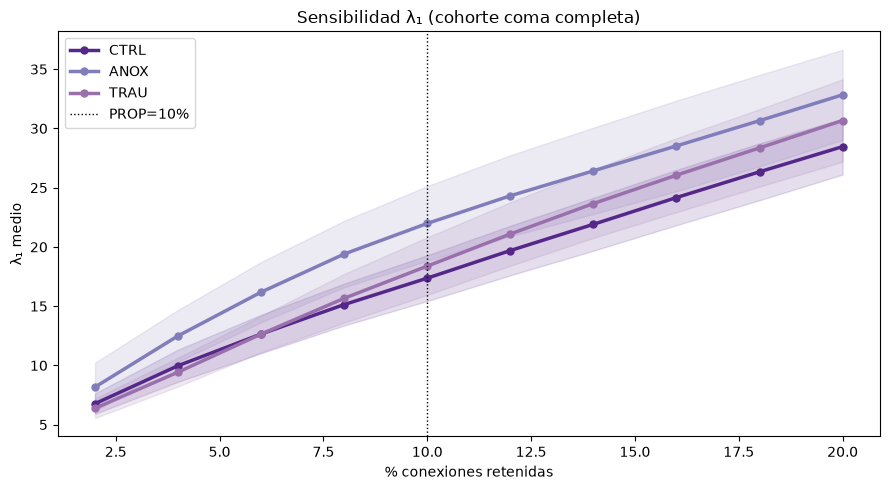

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
for g in DIAG_COMA:
    sub = sens_agg[sens_agg.diagnosis == g]
    ax.plot(sub["prop"] * 100, sub["lambda1_mean"], color=COLORS_CRIT[g], lw=2.5,
            marker="o", ms=5, label=g)
    ax.fill_between(sub["prop"] * 100,
                    sub["lambda1_mean"] - sub["lambda1_std"],
                    sub["lambda1_mean"] + sub["lambda1_std"],
                    color=COLORS_CRIT[g], alpha=0.15)
ax.axvline(PROP_CRIT * 100, color="k", ls=":", lw=1, label=f"PROP={PROP_CRIT*100:.0f}%")
ax.set_xlabel("% conexiones retenidas"); ax.set_ylabel("λ₁ medio")
ax.set_title("Sensibilidad λ₁ (cohorte coma completa)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "09_crit_sensibilidad.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Estadística grupal + metadatos

In [22]:
from scipy.stats import kruskal

# λ₁
H, p = kruskal(*[lambda1_df.loc[lambda1_df.diagnosis == g, "lambda1"] for g in DIAG_COMA])
print(f"λ₁ Kruskal-Wallis: H={H:.3f} p={p:.4g}")

stats_rows = []
for metric, df, col in [
    ("lambda1", lambda1_df, "lambda1"),
    ("lambda1_norm", lambda1_df, "lambda1_norm"),
]:
    H, p = kruskal(*[df.loc[df.diagnosis == g, col] for g in DIAG_COMA])
    stats_rows.append({"metric": metric, "H": H, "p": p})

for g1, g2 in [("CTRL", "ANOX"), ("CTRL", "TRAU"), ("ANOX", "TRAU")]:
    for col in ["lambda1", "lambda1_norm"]:
        a = lambda1_df.loc[lambda1_df.diagnosis == g1, col]
        b = lambda1_df.loc[lambda1_df.diagnosis == g2, col]
        _, p = mannwhitneyu(a, b, alternative="two-sided")
        stats_rows.append({"metric": f"{col}_{g1}_vs_{g2}", "H": np.nan, "p": p})

stats_df = pd.DataFrame(stats_rows)
stats_df["p_fdr"] = multipletests(stats_df["p"].fillna(1), method="fdr_bh")[1]
stats_df.to_csv(CRIT_OUT / "estadisticas_criticalidad.csv", index=False)
print(stats_df.round(4).to_string())

run_meta = {
    "n_coma": int(len(cohort_coma)),
    "n_redlat": int(len(cohort_rl)),
    "mae_cn_test": float(mae_cn),
    "N_PER_DX": N_PER_DX,
    "N_NULL": N_NULL,
    "CRIT_N_PER_DX": CRIT_N_PER_DX,
    "N_AVALANCHAS": N_AVALANCHAS,
    "PROP_CRIT": PROP_CRIT,
    "seed": cfg.seed,
}
with open(CRIT_OUT / "run_meta.json", "w") as f:
    json.dump(run_meta, f, indent=2)
with open(OUT / "transfer_meta.json", "w") as f:
    json.dump({**run_meta, "features": "Z+TOPO"}, f, indent=2)
print("Listo →", OUT)

λ₁ Kruskal-Wallis: H=14.402 p=0.0007459
                      metric       H       p   p_fdr
0                    lambda1  14.402  0.0007  0.0015
1               lambda1_norm  14.402  0.0007  0.0015
2       lambda1_CTRL_vs_ANOX     NaN  0.0002  0.0007
3  lambda1_norm_CTRL_vs_ANOX     NaN  0.0002  0.0007
4       lambda1_CTRL_vs_TRAU     NaN  0.2826  0.2826
5  lambda1_norm_CTRL_vs_TRAU     NaN  0.2826  0.2826
6       lambda1_ANOX_vs_TRAU     NaN  0.0089  0.0119
7  lambda1_norm_ANOX_vs_TRAU     NaN  0.0089  0.0119
Listo → outputs/nb09_coma
